In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("retail_sales_dataset.csv")

In [4]:
print(df.head())

   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  


In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB
None


In [6]:
print(df.isnull().sum())

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [7]:
df.drop_duplicates(inplace=True)

In [8]:
print("Total Sales:", df["Total Amount"].sum())

Total Sales: 456000


In [9]:
print("Average Sales:", df["Total Amount"].mean())

Average Sales: 456.0


In [10]:
print(df.groupby("Gender")["Total Amount"].sum())

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64


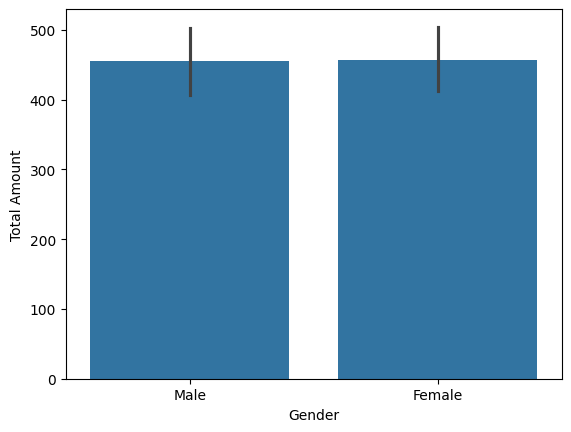

In [11]:
sns.barplot(x="Gender", y="Total Amount", data=df)

plt.show()

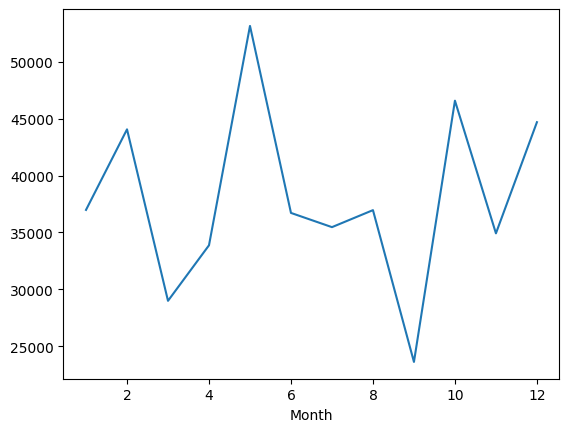

In [13]:
df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.month

monthly_sales = df.groupby('Month')['Total Amount'].sum()

monthly_sales.plot()

plt.show()

In [14]:
print(df.groupby("Product Category")["Total Amount"].sum())

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64


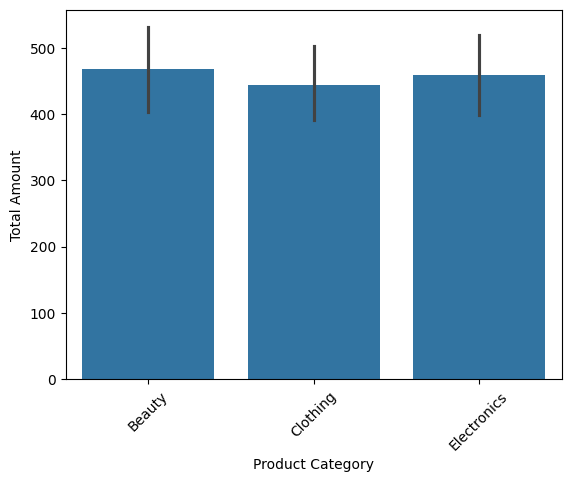

In [15]:
sns.barplot(x="Product Category", y="Total Amount", data=df)

plt.xticks(rotation=45)

plt.show()

In [17]:
df.to_csv("Retail_Sales_Cleaned.csv", index=False)

In [19]:
total_orders = df.shape[0]

print("Total Orders:", total_orders)

Total Orders: 1000


In [22]:
electronics = df[df["Product Category"] == "Electronics"]

print(electronics.head())

    Transaction ID       Date Customer ID  Gender  Age Product Category  \
2                3 2023-01-13     CUST003    Male   50      Electronics   
7                8 2023-02-22     CUST008    Male   30      Electronics   
8                9 2023-12-13     CUST009    Male   63      Electronics   
12              13 2023-08-05     CUST013    Male   22      Electronics   
14              15 2023-01-16     CUST015  Female   42      Electronics   

    Quantity  Price per Unit  Total Amount  Month  
2          1              30            30      1  
7          4              25           100      2  
8          2             300           600     12  
12         3             500          1500      8  
14         4             500          2000      1  
